In [32]:
import pandas as pd
import numpy as np
IKStrom=pd.read_csv("Daten IK8/2025_2 Hist Strom.csv",date_format='ISO8601',parse_dates=True,decimal='.')
IKStrom['last_changed dt']=pd.to_datetime(IKStrom['last_changed']).dt.floor('h')
IKStrom=IKStrom.set_index('last_changed dt')
#ent_filter=['sensor.haushalt_positive_active_energy_total','sensor.haushalt_negative_active_energy_total','sensor.waermepumpe_positive_active_energy_total','sensor.waermepumpe_negative_active_energy_total']
#IKStrom=IKStrom[IKStrom['entity_id'].isin(ent_filter)]
#IKStrom['state']=pd.to_numeric(IKStrom['state'])
#IKStrom=IKStrom.groupby('entity_id').resample('h')['state'].agg(['min']).ffill()
#IKStrom=IKStrom.reset_index().pivot(index=['last_changed dt'],columns='entity_id',values='min')
#IKStrom=IKStrom.ffill()

In [33]:
IKStrom

,entity_id,state,last_changed
last_changed dt,,,
2024-12-31 23:00:00+00:00,sensor.waermepumpe_positive_active_energy_total,19433236.5,2024-12-31T23:00:00.000Z
2025-01-01 00:00:00+00:00,sensor.waermepumpe_positive_active_energy_total,19433623.9,2025-01-01T00:00:00.000Z
2025-01-01 01:00:00+00:00,sensor.waermepumpe_positive_active_energy_total,19435945.9,2025-01-01T01:00:00.000Z
2025-01-01 02:00:00+00:00,sensor.waermepumpe_positive_active_energy_total,19436449.4,2025-01-01T02:00:00.000Z
2025-01-01 03:00:00+00:00,sensor.waermepumpe_positive_active_energy_total,19438615.9,2025-01-01T03:00:00.000Z
...,...,...,...
2025-06-09 17:00:00+00:00,switch.smarte_steckdose_tp01,on,2025-06-09T17:29:01.134Z
2025-06-09 17:00:00+00:00,switch.smarte_steckdose_tp01,off,2025-06-09T17:50:41.129Z
2025-05-26 15:00:00+00:00,switch.smarte_steckdose_tp01_automatische_absc...,off,2025-05-26T15:41:56.134Z


In [6]:
IKStrom.entity_id.unique()

array(['sensor.waermepumpe_positive_active_energy_total',
       'sensor.waermepumpe_positive_active_energy_in_tariff_t1',
       'sensor.waermepumpe_positive_active_energy_in_tariff_t2',
       'sensor.waermepumpe_negative_active_energy_total',
       'sensor.waermepumpe_negative_active_energy_in_tariff_t1',
       'sensor.waermepumpe_negative_active_energy_in_tariff_t2',
       'sensor.haushalt_positive_active_energy_total',
       'sensor.haushalt_positive_active_energy_in_tariff_t1',
       'sensor.haushalt_positive_active_energy_in_tariff_t2',
       'sensor.haushalt_negative_active_energy_total',
       'sensor.haushalt_negative_active_energy_in_tariff_t1',
       'sensor.haushalt_negative_active_energy_in_tariff_t2',
       'sensor.waermepumpe_sum_active_instantaneous_power',
       'sensor.haushalt_sum_active_instantaneous_power',
       'number.heat_pump_temperatur',
       'number.smarte_steckdose_tp01_ausschalten_in',
       'sensor.smarte_steckdose_tp01_signalpegel',
      

In [34]:
ent_filter=['switch.smarte_steckdose_tp01','sensor.heat_pump_temperatur','switch.heat_pump_schalter']
IKStrom=IKStrom[IKStrom['entity_id'].isin(ent_filter)]
IKStrom=IKStrom[IKStrom['state'].ne('unavailable')]

In [35]:
IKStrom

,entity_id,state,last_changed
last_changed dt,,,
2025-05-12 16:00:00+00:00,sensor.heat_pump_temperatur,25.129965845662213,2025-05-12T16:00:00.000Z
2025-05-12 17:00:00+00:00,sensor.heat_pump_temperatur,23.730010607194444,2025-05-12T17:00:00.000Z
2025-05-12 18:00:00+00:00,sensor.heat_pump_temperatur,19.000209820805555,2025-05-12T18:00:00.000Z
2025-05-12 19:00:00+00:00,sensor.heat_pump_temperatur,16.48775095761111,2025-05-12T19:00:00.000Z
2025-05-12 20:00:00+00:00,sensor.heat_pump_temperatur,15.197250192527777,2025-05-12T20:00:00.000Z
...,...,...,...
2025-06-09 17:00:00+00:00,switch.smarte_steckdose_tp01,off,2025-06-09T17:27:31.129Z
2025-06-09 17:00:00+00:00,switch.smarte_steckdose_tp01,on,2025-06-09T17:27:46.141Z
2025-06-09 17:00:00+00:00,switch.smarte_steckdose_tp01,off,2025-06-09T17:28:56.127Z


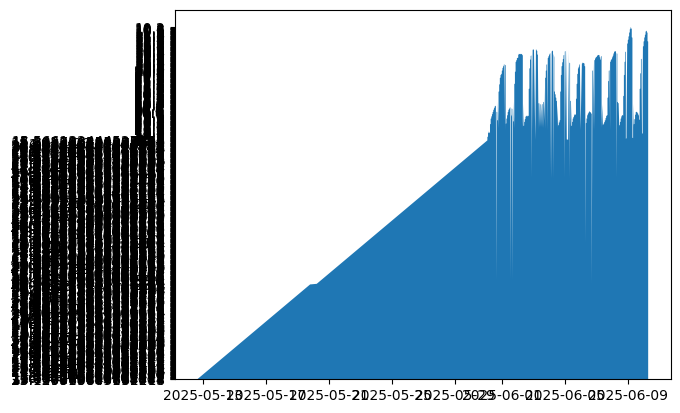

In [31]:
import matplotlib.pyplot as plt
plt.stackplot(IKStrom[IKStrom['entity_id']=='sensor.heat_pump_temperatur'].index,IKStrom[IKStrom['entity_id']=='sensor.heat_pump_temperatur']['state'])

In [36]:
IKStrom=IKStrom.groupby('entity_id').resample('h')['state'].agg(['min']).ffill()
IKStrom=IKStrom.reset_index().pivot(index=['last_changed dt'],columns='entity_id',values='min')
IKStrom=IKStrom.ffill()

In [41]:
IKStrom

entity_id,sensor.heat_pump_temperatur,switch.heat_pump_schalter,switch.smarte_steckdose_tp01,AVG_TA200,SUM_GS200,SUM_NN050
last_changed dt,,,,,,
2025-05-12 16:00:00+00:00,25.129965845662213,NaN,NaN,19.3,434.0,0.0
2025-05-12 17:00:00+00:00,23.730010607194444,NaN,NaN,19.4,373.5,0.0
2025-05-12 18:00:00+00:00,19.000209820805555,NaN,NaN,18.4,196.3,0.0
2025-05-12 19:00:00+00:00,16.48775095761111,NaN,NaN,15.6,25.6,3.9
2025-05-12 20:00:00+00:00,15.197250192527777,NaN,NaN,14.2,0.0,0.0
...,...,...,...,...,...,...
2025-06-10 03:00:00+00:00,11.0,off,off,10.0,0.0,0.0
2025-06-10 04:00:00+00:00,10.8,off,off,9.5,0.0,0.0
2025-06-10 05:00:00+00:00,10.8,off,off,8.5,0.0,0.0


In [39]:
wetter=pd.read_csv('Wetter/2022ff_Wetter_Station_020_Mengen_hh24.csv',sep=';',decimal=',')
wetter['Datum']=pd.to_datetime(wetter['Tag']+' '+wetter['Stunde'],format='%d.%m.%Y %H:%M',utc=True)
wetter=wetter.set_index('Datum')
IKStrom['AVG_TA200']=wetter['AVG_TA200']
IKStrom['SUM_GS200']=wetter['SUM_GS200']
IKStrom['SUM_NN050']=wetter['SUM_NN050']

In [42]:
IKStrom.to_csv('test.csv')